In [2]:
import os
                                                                
os.getcwd()

'C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600'

# Data Cleaning

In [4]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Climate Data

In [4]:
#!/usr/bin/env python3
import time
import re
import requests
from pathlib import Path
from typing import List, Tuple

# Precompiled regex to pull filename from Content-Disposition
_CD_FILENAME_RE = re.compile(r'filename\*?=(?:UTF-8\'\')?"?([^";]+)"?', re.IGNORECASE)

def download_prism_monthly(
    clim_var: str,
    start_year: int = 2014,
    end_year: int = 2025,
    out_dir: str | Path = "prism_monthly_downloads",
    base_url: str = "https://services.nacse.org/prism/data/get/us/4km",
    sleep_seconds: float = 2.0,
    retries: int = 3,
    timeout: int = 60,
) -> Tuple[List[Path], List[Tuple[int, int]]]:
    """
    Download all PRISM monthly files for a variable and year range.

    Returns:
        (downloaded_files, failures)
        downloaded_files: list of Paths for successfully saved files
        failures: list of (year, month) that failed after all attempts
    """
    session = requests.Session()
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    def _save_response(resp: requests.Response, fallback_name: str) -> Path:
        fn = None
        cd = resp.headers.get("Content-Disposition", "")
        m = _CD_FILENAME_RE.search(cd)
        if m:
            fn = m.group(1)
        if not fn:
            fn = fallback_name
        dest = out_path / fn
        # Skip if already present and non-empty
        if dest.exists() and dest.stat().st_size > 0:
            return dest
        with open(dest, "wb") as f:
            for chunk in resp.iter_content(chunk_size=1 << 15):
                if chunk:
                    f.write(chunk)
        return dest

    def _fetch_month(year: int, month: int) -> Path | None:
        # Try common monthly forms: YYYYMM then YYYYMM01
        date_candidates = [f"{year}{month:02d}", f"{year}{month:02d}01"]
        for i, date_str in enumerate(date_candidates):
            url = f"{base_url}/{clim_var}/{date_str}"
            fallback_name = f"prism_{clim_var}_{date_str}.zip"
            for attempt in range(1, retries + 1):
                try:
                    resp = session.get(url, stream=True, timeout=timeout)
                    if resp.status_code == 200:
                        return _save_response(resp, fallback_name)
                except requests.RequestException:
                    pass
                time.sleep(0.5 * attempt + 0.5)  # small backoff
            if i == 0:
                # try alternate format next
                continue
        return None

    downloaded: List[Path] = []
    failures: List[Tuple[int, int]] = []

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            p = _fetch_month(year, month)
            if p is not None:
                downloaded.append(p)
            else:
                failures.append((year, month))
            time.sleep(sleep_seconds)  # be nice to the server

    return downloaded, failures

### Precipitation

In [35]:
download_prism_monthly('ppt')

([WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202401.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202402.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202403.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202404.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202405.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202406.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202407.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202408.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202409.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202410.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202411.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202412.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202501.zip'),
  WindowsPath('prism_monthly_downloads/prism_ppt_us_25m_202502.zip'),
  WindowsPath('prism

In [37]:
download_prism_monthly('tmax')

([WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202401.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202402.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202403.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202404.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202405.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202406.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202407.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202408.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202409.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202410.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202411.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202412.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202501.zip'),
  WindowsPath('prism_monthly_downloads/prism_tmax_us_25m_202502.zip'),
  Wind

### Fixing the Climate Data

Once downloaded, I used ArcGIS Pro to create zonal statistics tables for each of the files, then merged them into one table. The input zone file was a shapefile containing the boundaries of each county in California.

In [6]:
climate_data = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\all_prism_hr_stats.csv')

climate_data.head()

,HR_NAME,ZONE_CODE,COUNT,AREA,MEAN,variable,year_month,year,month
0,Central Coast,1,1680.0,2.916667,0.981684,ppt,201401,2014,1
1,Colorado River,2,2881.0,5.001736,0.181380,ppt,201401,2014,1
2,North Coast,3,3088.0,5.361111,38.527831,ppt,201401,2014,1
3,North Lahontan,4,972.0,1.687500,28.857209,ppt,201401,2014,1
4,Sacramento River,5,4273.0,7.418403,17.891575,ppt,201401,2014,1


In [8]:
climate_data = pd.pivot_table(climate_data,
                              values='MEAN',
                              index=['HR_NAME', 'year_month', 'year', 'month'],
                              columns='variable',
                              aggfunc='first').reset_index()

climate_data.columns.name = None
climate_data = climate_data[(climate_data['year_month'] >= 201406) & (climate_data['year_month'] <= 202305)]
climate_data['year_month'] = pd.to_datetime(climate_data['year_month'], format='%Y%m').dt.to_period('M')

In [10]:
climate_data = climate_data.rename(columns={'HR_NAME': 'region',
                                            'year_month': 'report_date'})
climate_data['report_date'] = pd.to_datetime(climate_data[['year', 'month']].assign(day=1))
climate_data.head()

,region,report_date,year,month,ppt,tmax
5,Central Coast,2014-06-01,2014,6,0.014606,28.105426
6,Central Coast,2014-07-01,2014,7,0.144071,30.492118
7,Central Coast,2014-08-01,2014,8,0.170748,29.741007
8,Central Coast,2014-09-01,2014,9,2.119133,29.038373
9,Central Coast,2014-10-01,2014,10,1.744980,27.329460


## Water Usage/Population Data

In [12]:
water_usage = pd.read_excel('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\uw_supplier_data071423.xlsx')

### DRINC Dataset (June 2014-April 2023)

In [13]:
# for this dataset, we will be using total water produced as a reliable substitute to explicit water use
# the DRINC dataset did not require explicit reporting on total water use, so total supply (water produced) is a sufficient substitute

# there are many NaNs in commercial agriculture reporting
# the State Water Resources Control Board provides a Monthly Conservation Reporting Definitions and Data Dictionary
# commercial agricultural water gallons is calculated by the Board --> NaNs should be imputed as 0

# total water use
water_usage['water_use'] = (
    water_usage['CALCULATED Total Potable Water Production Gallons (Ag Excluded)'] +
    water_usage['CALCULATED Commercial Agricultural Water Gallons'].fillna(0)
)

In [14]:
water_usage['month'] = water_usage['Reporting Month'].dt.month
water_usage['year'] = water_usage['Reporting Month'].dt.year

keep_columns = ['Supplier Name', 'Hydrologic Region', 'Reporting Month', 'month', 'year',
                'Total Population Served', 'water_use']

water_usage = water_usage[keep_columns]
water_usage['Reporting Month'] = water_usage['Reporting Month'].dt.to_period('M')
water_usage.head()

,Supplier Name,Hydrologic Region,Reporting Month,month,year,Total Population Served,water_use
0,East Bay Municipal Utilities District,San Francisco Bay,2023-04,4,2023,1440000,4.026000e+09
1,East Bay Municipal Utilities District,San Francisco Bay,2023-03,3,2023,1440000,3.672000e+09
2,East Bay Municipal Utilities District,San Francisco Bay,2023-02,2,2023,1440000,3.358000e+09
3,East Bay Municipal Utilities District,San Francisco Bay,2023-01,1,2023,1440000,3.696000e+09
4,East Bay Municipal Utilities District,San Francisco Bay,2022-12,12,2022,1430000,3.722000e+09


In [15]:
# aggregating by Hydrologic Region and Reporting Month
# multiple suppliers per region/month pair

water_usage = water_usage.rename(columns={
    'Hydrologic Region': 'region',
    'Reporting Month': 'date',
    'Total Population Served': 'population'
})

# aggregate
water_usage = water_usage.groupby(['region', 'year', 'month']).agg({
    'water_use': 'sum',
    'population': 'sum'  # Numerator for weighted average
}).reset_index()

# For SARIMAX baseline
water_usage['report_date'] = pd.to_datetime(water_usage[['year', 'month']].assign(day=1))

water_usage.head()

,region,year,month,water_use,population,report_date
0,Central Coast,2014,6,5.604272e+09,1222138,2014-06-01
1,Central Coast,2014,7,5.939228e+09,1245629,2014-07-01
2,Central Coast,2014,8,5.393243e+09,1215476,2014-08-01
3,Central Coast,2014,9,5.215423e+09,1247651,2014-09-01
4,Central Coast,2014,10,4.989570e+09,1247984,2014-10-01


## Land Use/Cover Data

Downloaded the data from https://www.mrlc.gov/data?cookiesession8341=8C7E0028387F1523016F33B01FBF78C3. Once downloaded, I used the Tabulate Area tool in ArcGIS Pro to calculate the area of each land cover type in each of the 10 hydrologic regions in California.

In [16]:
land_cover = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\nlcd_all_years.csv')

land_cover = land_cover[land_cover['year'] <= 2023]
land_cover.head()

,HR_NAME,VALUE_11,VALUE_12,VALUE_21,VALUE_22,VALUE_23,VALUE_24,VALUE_31,VALUE_41,VALUE_42,VALUE_43,VALUE_52,VALUE_71,VALUE_81,VALUE_82,VALUE_90,VALUE_95,year
0,Central Coast,47744100.0,0.0,6.369696e+08,5.069853e+08,322019100.0,46317600.0,9.185940e+07,10123200.0,2.470253e+09,2.001796e+09,1.142667e+10,9.252747e+09,25725600.0,2.023987e+09,169335900.0,224539200.0,2014
1,Colorado River,983008800.0,25200.0,3.044691e+08,5.050728e+08,272112300.0,31315500.0,8.891448e+09,849600.0,3.171060e+08,2.282760e+07,3.679160e+10,4.348377e+08,3543300.0,2.679774e+09,153693900.0,49166100.0,2014
2,North Coast,329064300.0,2847600.0,9.867555e+08,5.144364e+08,174987000.0,28646100.0,3.494583e+08,526204800.0,2.824471e+10,6.414012e+08,1.216990e+10,4.355010e+09,634530600.0,7.772661e+08,209680200.0,418447800.0,2014
3,North Lahontan,469074600.0,1266300.0,1.624734e+08,1.605078e+08,29223900.0,3291300.0,7.465230e+08,82265400.0,4.080254e+09,0.000000e+00,7.971116e+09,1.166688e+09,242864100.0,1.753686e+08,259701300.0,301790700.0,2014
4,Sacramento River,911626200.0,3033000.0,1.915036e+09,1.363327e+09,785322000.0,140517900.0,6.193458e+08,564254100.0,2.618405e+10,1.937052e+08,1.690438e+10,1.024303e+10,578247300.0,8.664033e+09,457428600.0,943782300.0,2014


In [17]:
value_cols = [c for c in land_cover.columns if c.startswith('VALUE_')]

land_cover['total_area'] = land_cover[value_cols].sum(axis=1)
for col in value_cols:
    land_cover[col] = land_cover[col] / land_cover['total_area']

land_cover['pct_developed'] = land_cover[['VALUE_21', 'VALUE_22', 'VALUE_23', 'VALUE_24']].sum(axis=1)
land_cover['pct_agriculture'] = land_cover[['VALUE_81', 'VALUE_82']].sum(axis=1)
land_cover['pct_forest'] = land_cover[['VALUE_41', 'VALUE_42', 'VALUE_43']].sum(axis=1)
land_cover['pct_shrub_grass'] = land_cover[['VALUE_52', 'VALUE_71']].sum(axis=1)

land_cover.rename(columns={'HR_NAME': 'region'}, inplace=True)

land_2024 = land_cover[land_cover['year'] == 2024].copy()
land_2024['year'] = 2025
land_cover = pd.concat([land_cover, land_2024], ignore_index=True)

land_cover.drop(columns=value_cols, inplace=True)
land_cover.drop(columns='total_area', inplace=True)
land_cover.head()

,region,year,pct_developed,pct_agriculture,pct_forest,pct_shrub_grass
0,Central Coast,2014,0.051690,0.070059,0.153200,0.706818
1,Colorado River,2014,0.021636,0.052163,0.006625,0.723675
2,North Coast,2014,0.033851,0.028032,0.584002,0.328114
3,North Lahontan,2014,0.022425,0.026383,0.262580,0.576430
4,Sacramento River,2014,0.059659,0.131150,0.382313,0.385227


## Merging Water Usage, Climate, and Land Use Data

In [18]:
len(water_usage) == len(climate_data)

True

In [19]:
final = water_usage.merge(climate_data,
                        on=['region', 'year', 'month'],
                        how='inner')

if 'report_date_x' in final.columns:
    final = final.rename(columns={'report_date_x': 'report_date'})
    final = final.drop(columns=['report_date_y'])

final = final.merge(land_cover, on=['region', 'year'], how='left')

## Additional Derived Features

### Lagged Water Use

In [29]:
final = final.sort_values(['region', 'year', 'month'])

# Lag features
final['water_use_lastmonth'] = final.groupby('region')['water_use'].shift(1)  # Previous month
final['water_use_lastyear'] = final.groupby('region')['water_use'].shift(12)  # Same month last year

# Rolling averages
final['water_use_last3month_avg'] = final.groupby('region')['water_use'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

### Climate

In [31]:
# 3 month precipitation total, captures drought buildup
final['ppt_3month_total'] = final.groupby('region')['ppt'].transform(
    lambda x: x.rolling(3, min_periods=1).sum())

# 3 month average temperature
final['tmax_3month_avg'] = final.groupby('region')['tmax'].transform(
    lambda x: x.rolling(3, min_periods=1).mean())

### Seasonality

In [33]:
# cyclical encoding for months, helps with seasonality influence on water usage
final['month_sin'] = np.sin(2 * np.pi * final['month'] / 12)
final['month_cos'] = np.cos(2 * np.pi * final['month'] / 12)

### Column Ordering and Exporting to CSV

In [35]:
col_order = ['region', 'report_date', 'year', 'month', 
             'month_sin', 'month_cos',
             'ppt', 'ppt_3month_total',
             'tmax', 'tmax_3month_avg',
             'population',
             'pct_developed', 'pct_agriculture', 'pct_forest', 'pct_shrub_grass',
             'water_use_lastmonth', 'water_use_lastyear', 'water_use_last3month_avg', 'water_use']

final = final[col_order]
final.head()

,region,report_date,year,month,month_sin,month_cos,ppt,ppt_3month_total,tmax,tmax_3month_avg,population,pct_developed,pct_agriculture,pct_forest,pct_shrub_grass,water_use_lastmonth,water_use_lastyear,water_use_last3month_avg,water_use
0,Central Coast,2014-06-01,2014,6,1.224647e-16,-1.000000e+00,0.014606,0.014606,28.105426,28.105426,1222138,0.05169,0.070059,0.1532,0.706818,NaN,NaN,NaN,5.604272e+09
1,Central Coast,2014-07-01,2014,7,-5.000000e-01,-8.660254e-01,0.144071,0.158677,30.492118,29.298772,1245629,0.05169,0.070059,0.1532,0.706818,5.604272e+09,NaN,NaN,5.939228e+09
2,Central Coast,2014-08-01,2014,8,-8.660254e-01,-5.000000e-01,0.170748,0.329425,29.741007,29.446184,1215476,0.05169,0.070059,0.1532,0.706818,5.939228e+09,NaN,NaN,5.393243e+09
3,Central Coast,2014-09-01,2014,9,-1.000000e+00,-1.836970e-16,2.119133,2.433952,29.038373,29.757166,1247651,0.05169,0.070059,0.1532,0.706818,5.393243e+09,NaN,5.645581e+09,5.215423e+09
4,Central Coast,2014-10-01,2014,10,-8.660254e-01,5.000000e-01,1.744980,4.034860,27.329460,28.702946,1247984,0.05169,0.070059,0.1532,0.706818,5.215423e+09,NaN,5.515965e+09,4.989570e+09


In [37]:
final.columns

Index(['region', 'report_date', 'year', 'month', 'month_sin', 'month_cos',
       'ppt', 'ppt_3month_total', 'tmax', 'tmax_3month_avg', 'population',
       'pct_developed', 'pct_agriculture', 'pct_forest', 'pct_shrub_grass',
       'water_use_lastmonth', 'water_use_lastyear', 'water_use_last3month_avg',
       'water_use'],
      dtype='object')

In [104]:
final.shape

(1080, 19)

In [136]:
final.to_csv('all_data.csv', index=False)

In [6]:
final = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\all_data.csv')

# Exploratory Analysis

## Summary Statistics

In [81]:
summary_cols = ['region', 'ppt', 'tmax', 'population', 'pct_developed', 'pct_agriculture',
                'pct_forest', 'pct_shrub_grass', 'water_use']
summary = final[summary_cols].groupby("region").agg(['mean', 'std', 'min', 'max'])
summary.columns = ['_'.join(col) for col in summary.columns]

summary.to_csv('summary_stats.csv', index=True)

## Temporal Trends

In [68]:
# water use
annual_trends = final[['year', 'water_use']].groupby('year').agg('sum')  # yearly trend
monthly_trends = final[['month', 'water_use']].groupby('month').agg('mean')  # monthly trend

print(annual_trends)  # no clear trend; 2014 and 2023 are not full years
print(monthly_trends)  # peaks in summary months, namely July and August

         water_use
year              
2014  1.251867e+12
2015  1.709924e+12
2016  1.722678e+12
2017  1.812464e+12
2018  1.787180e+12
2019  1.647721e+12
2020  1.826053e+12
2021  1.851129e+12
2022  1.782503e+12
2023  5.044319e+11
          water_use
month              
1      1.058635e+10
2      1.038246e+10
3      1.150636e+10
4      1.321473e+10
5      1.541324e+10
6      1.791890e+10
7      1.957300e+10
8      1.955336e+10
9      1.782416e+10
10     1.623184e+10
11     1.320113e+10
12     1.121615e+10


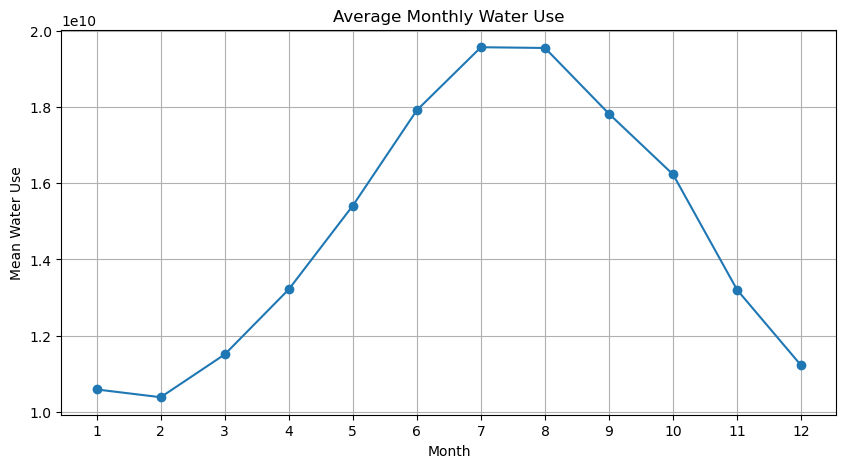

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_trends.index, monthly_trends['water_use'], marker='o')
plt.xlabel("Month")
plt.ylabel("Mean Water Use")
plt.title("Average Monthly Water Use")
plt.xticks(monthly_trends.index)  # ensure all months show
plt.grid(True)
plt.savefig('average_monthly_water_use.png')
plt.show()

## Correlation Analysis

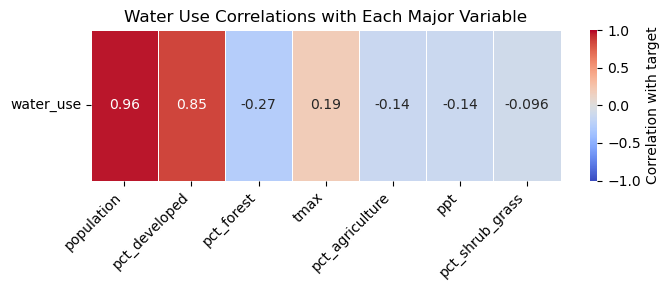

In [41]:
corr_columns = ['ppt', 'tmax', 'population', 'pct_developed', 'pct_agriculture',
                'pct_forest', 'pct_shrub_grass', 'water_use']
target = 'water_use'   # ← change this

# Compute numeric correlations
corr_series = final[corr_columns].corr()[target].drop(target)

corr_series = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

corr_df = pd.DataFrame(corr_series).T
corr_df.index = [target]   # name the row

plt.figure(figsize=(max(7, len(corr_df.columns) * 0.5), 3))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=.5,
    cbar_kws={"label": "Correlation with target"}
)

plt.title('Water Use Correlations with Each Major Variable')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('water_use_correlations.png')
plt.show()

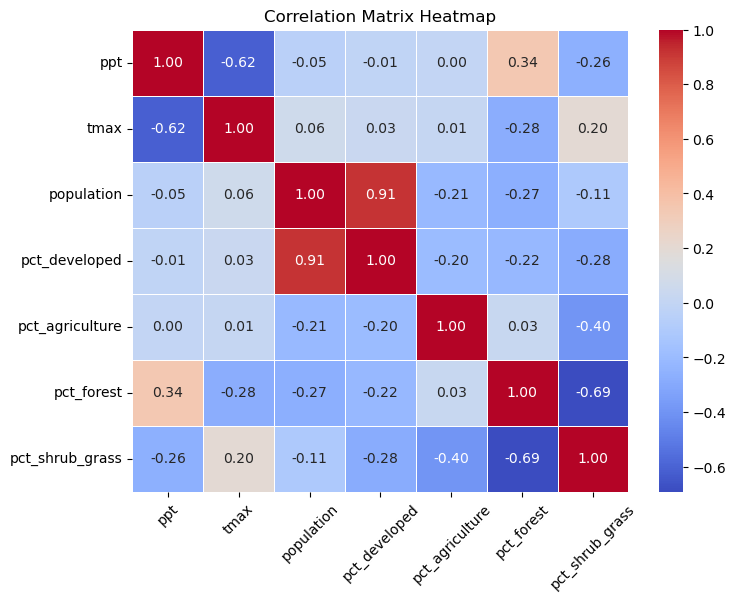

In [91]:
corr_columns = ['ppt', 'tmax', 'population', 'pct_developed', 'pct_agriculture',
                'pct_forest', 'pct_shrub_grass']

corr_matrix = final[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.xticks(rotation=45)
plt.title('Correlation Matrix Heatmap')
plt.savefig('corr_matrix.png')
plt.show()

# Model Building

This project will focus on scenario-based modeling. In other words, we assume that we know, or otherwise specify, the current month's environment (climate, demographics, land-use, etc.).

In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn import set_config
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

## SARIMAX Baseline

### All Regions

In [43]:
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SARIMAX FOR ALL REGIONS
# ============================================================

# Storage for results
all_results = []
all_predictions = []
model_objects = {}

# Get unique regions
regions = final['region'].unique()
print(f"Building SARIMAX models for {len(regions)} regions\n")

for region_name in regions:
    print(f"{'='*60}")
    print(f"Region: {region_name}")
    print('='*60)
    
    # Prepare data for this region
    region_data = final[final['region'] == region_name].copy()
    region_data = region_data.sort_values('report_date')
    region_data = region_data.set_index('report_date')
    
    # Scale target to millions
    y = region_data['water_use'] / 1_000_000
    
    # Standardize exogenous variables
    exog_raw = region_data[['population', 'ppt', 'tmax',
                            'ppt_3month_total', 'tmax_3month_avg',
                            'month_sin', 'month_cos']]
    scaler = StandardScaler()
    exog_scaled = scaler.fit_transform(exog_raw)
    exog = pd.DataFrame(
        exog_scaled, 
        columns=['population', 'ppt', 'tmax',
                 'ppt_3month_total', 'tmax_3month_avg',
                 'month_sin', 'month_cos'], 
        index=exog_raw.index
    )
    
    # Train/test split (last 12 months as test)
    train_size = len(y) - 12
    y_train, y_test = y[:train_size], y[train_size:]
    exog_train, exog_test = exog[:train_size], exog[train_size:]
    
    print(f"Training size: {len(y_train)} months")
    print(f"Test size: {len(y_test)} months")
    
    try:
        # Fit SARIMAX model
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False, maxiter=200)
        
        # Forecast
        forecast = results.forecast(steps=len(y_test), exog=exog_test)
        
        # Convert back to original scale for evaluation
        forecast_gallons = forecast * 1_000_000
        y_test_gallons = y_test * 1_000_000
        
        # Calculate metrics
        mae = mean_absolute_error(y_test_gallons, forecast_gallons)
        rmse = np.sqrt(mean_squared_error(y_test_gallons, forecast_gallons))
        r2 = r2_score(y_test_gallons, forecast_gallons)
        mape = np.mean(np.abs((y_test_gallons - forecast_gallons) / y_test_gallons)) * 100
        
        print(f"MAE: {mae:,.0f} gallons")
        print(f"RMSE: {rmse:,.0f} gallons")
        print(f"R²: {r2:.3f}")
        print(f"MAPE: {mape:.1f}%")
        print(f"AIC: {results.aic:.2f}")
        
        # Store results
        all_results.append({
            'region': region_name,
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'mape': mape,
            'aic': results.aic,
            'train_size': len(y_train),
            'test_size': len(y_test)
        })
        
        # Store predictions for later analysis
        all_predictions.append({
            'region': region_name,
            'actual': y_test_gallons,
            'predicted': forecast_gallons,
            'dates': y_test.index
        })
        
        # Store model object
        model_objects[region_name] = {
            'results': results,
            'scaler': scaler
        }
        
        print("✓ Success\n")
        
    except Exception as e:
        print(f"✗ Error: {e}\n")
        all_results.append({
            'region': region_name,
            'mae': np.nan,
            'rmse': np.nan,
            'r2': np.nan,
            'mape': np.nan,
            'aic': np.nan,
            'train_size': len(y_train),
            'test_size': len(y_test)
        })

# ============================================================
# SUMMARY STATISTICS
# ============================================================

results_df = pd.DataFrame(all_results)

print("\n" + "="*60)
print("SARIMAX RESULTS - ALL REGIONS")
print("="*60)
print(results_df.sort_values('r2', ascending=False).to_string(index=False))

print("\n" + "="*60)
print("AGGREGATE STATISTICS")
print("="*60)
print(f"Average R²: {results_df['r2'].mean():.3f}")
print(f"Median R²: {results_df['r2'].median():.3f}")
print(f"Average MAE: {results_df['mae'].mean():,.0f} gallons")
print(f"Average RMSE: {results_df['rmse'].mean():,.0f} gallons")
print(f"\nBest performing region: {results_df.loc[results_df['r2'].idxmax(), 'region']} (R² = {results_df['r2'].max():.3f})")
print(f"Worst performing region: {results_df.loc[results_df['r2'].idxmin(), 'region']} (R² = {results_df['r2'].min():.3f})")

# Save results
results_df.to_csv("sarimax_results_by_region.csv", index=False)
print(f"\nResults saved to: sarimax_results_by_region.csv")

Building SARIMAX models for 10 regions

Region: Central Coast
Training size: 96 months
Test size: 12 months
MAE: 313,971,852 gallons
RMSE: 332,009,024 gallons
R²: 0.883
MAPE: 8.5%
AIC: 933.02
✓ Success

Region: Colorado River
Training size: 96 months
Test size: 12 months
MAE: 359,318,804 gallons
RMSE: 404,610,690 gallons
R²: 0.911
MAPE: 7.4%
AIC: 1001.83
✓ Success

Region: North Coast
Training size: 96 months
Test size: 12 months
MAE: 92,595,937 gallons
RMSE: 117,777,790 gallons
R²: 0.758
MAPE: 8.2%
AIC: 840.12
✓ Success

Region: North Lahontan
Training size: 96 months
Test size: 12 months
MAE: 71,812,535 gallons
RMSE: 80,500,162 gallons
R²: 0.736
MAPE: 26.9%
AIC: 657.73
✓ Success

Region: Sacramento River
Training size: 96 months
Test size: 12 months
MAE: 1,482,303,239 gallons
RMSE: 2,227,297,189 gallons
R²: 0.840
MAPE: 12.0%
AIC: 1183.82
✓ Success

Region: San Francisco Bay
Training size: 96 months
Test size: 12 months
MAE: 1,126,731,372 gallons
RMSE: 1,272,325,137 gallons
R²: 0.902


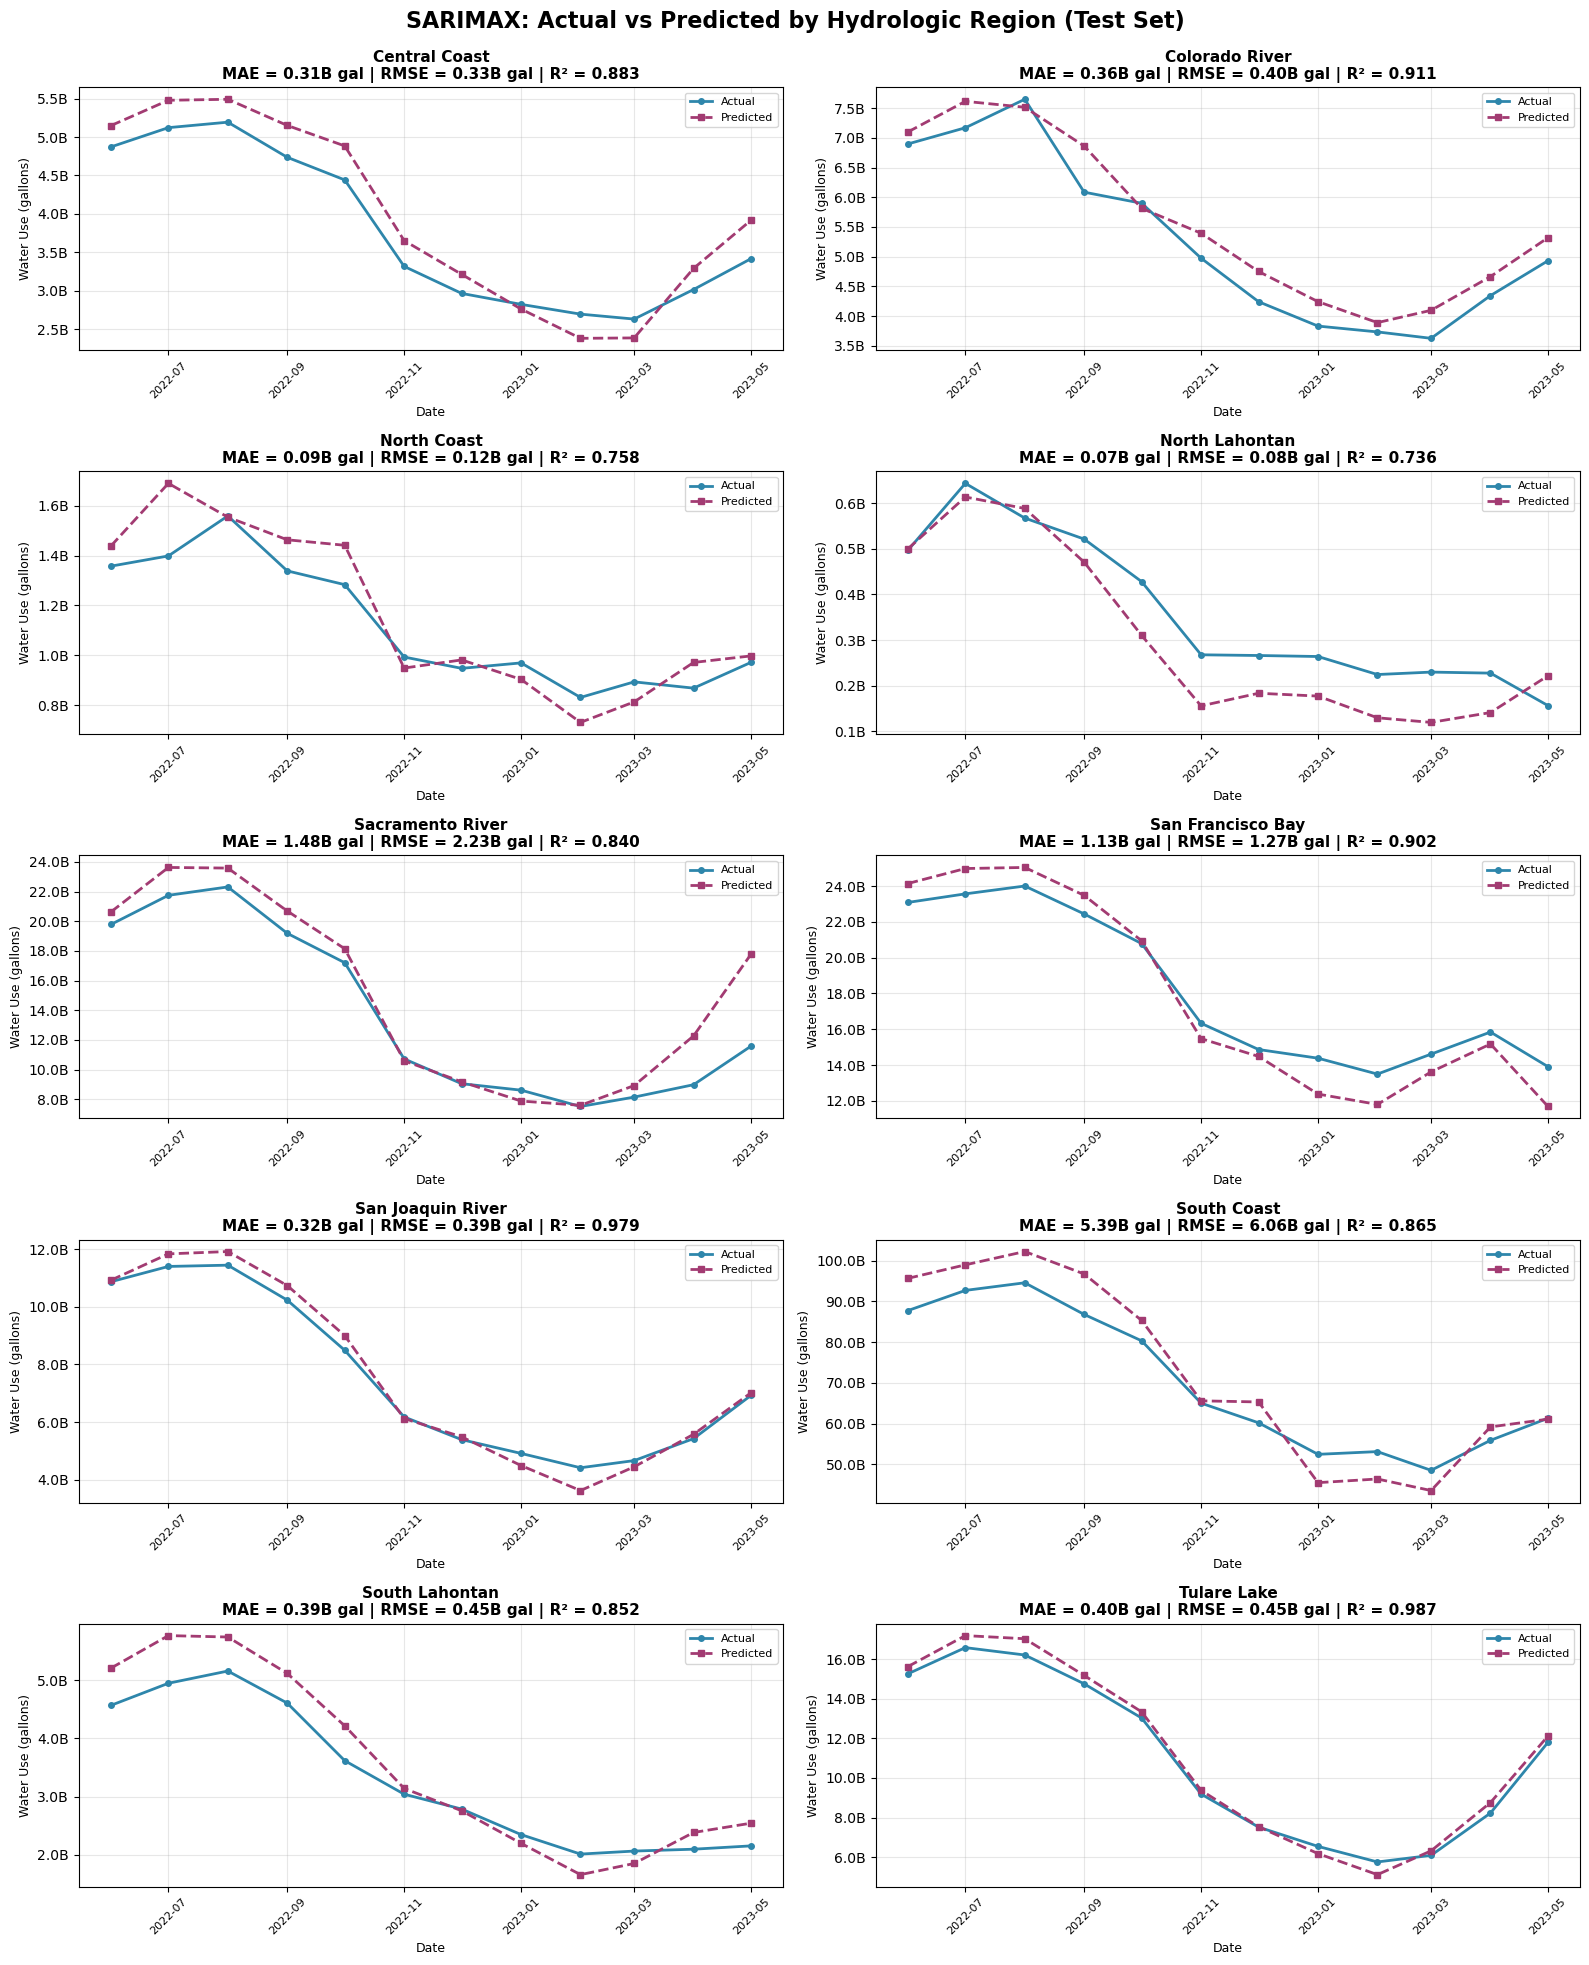

In [44]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, pred_data in enumerate(all_predictions):
    ax = axes[idx]
    region = pred_data['region']
    
    # Ensure all arrays same length
    dates = pred_data['dates']
    actual = np.array(pred_data['actual'])
    predicted = np.array(pred_data['predicted'])
    
    min_len = min(len(dates), len(actual), len(predicted))
    dates = dates[:min_len]
    actual = actual[:min_len]
    predicted = predicted[:min_len]
    
    # Plot
    ax.plot(dates, actual, label='Actual', marker='o', linewidth=2, markersize=4, color='#2E86AB')
    ax.plot(dates, predicted, label='Predicted', marker='s', linestyle='--', linewidth=2, markersize=4, color='#A23B72')
    
    # Get metrics
    r2 = results_df[results_df['region'] == region]['r2'].values[0]
    mae = results_df[results_df['region'] == region]['mae'].values[0]
    rmse = results_df[results_df['region'] == region]['rmse'].values[0]
    
    ax.set_title(f"{region}\nMAE = {mae/1e9:.2f}B gal | RMSE = {rmse/1e9:.2f}B gal | R² = {r2:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Water Use (gallons)', fontsize=9)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

plt.suptitle('SARIMAX: Actual vs Predicted by Hydrologic Region (Test Set)\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sarimax_all_regions.png', dpi=300, bbox_inches='tight')
plt.show()

## XGBoost

In [47]:
X = final.sort_values(['report_date', 'region']).drop(columns=['water_use', 'report_date'])
y = final.sort_values(['report_date', 'region'])['water_use']

train_size = len(y) - 120 # 12 months of test multiplied by 10 regions
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
y_train_log = np.log1p(y_train)

print(f"XGBoost Training samples: {len(X_train)}")
print(f"XGBoost Test samples: {len(X_test)}")

XGBoost Training samples: 960
XGBoost Test samples: 120


In [49]:
set_config(display='diagram')

one_hot = OneHotEncoder(handle_unknown='ignore')
xgb = XGBRegressor(eval_metric='rmse',
                   random_state=52)

preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', one_hot, ['region'])
    ],
    remainder='passthrough'
)

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb)
])

xgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, ev...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [51]:
search_space = {
    'xgb__n_estimators':    Integer(1000, 2000),
    'xgb__learning_rate':   Real(0.01, 0.1),
    'xgb__max_depth':       Integer(4, 10),
    'xgb__min_child_weight':Integer(1, 10),
    'xgb__subsample':       Real(0, 1.0),
    'xgb__colsample_bytree':Real(0, 1.0),
    'xgb__gamma':           Real(0, 0.5),
    'xgb__reg_lambda':      Real(1, 10),
    'xgb__reg_alpha':       Real(0, 1.0)
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_tuned = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_space,
    n_iter=60,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit='neg_root_mean_squared_error',
    return_train_score=True,
    random_state=52,
    verbose=0
)

xgb_tuned

BayesSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
              estimator=Pipeline(steps=[('preprocessor',
                                         ColumnTransformer(remainder='passthrough',
                                                           transformers=[('nominal',
                                                                          OneHotEncoder(handle_unknown='ignore'),
                                                                          ['region'])])),
                                        ('xgb',
                                         XGBRegressor(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_byno...
                             'xgb__min_child_weight': Integer(low=1, high=10, prior='uniform', transform='identity'),
                             'xgb__n_estimators': Integer(low=1000, high=2000, prior='uniform', transform='identity'),
                             'xgb__reg_alpha': Real(low=0, high=1.0, prior='uniform', transform='identity'),
                             'xgb__reg_lambda': Real(low=1, high=10, prior='uniform', transform='identity'),
                             'xgb__subsample': Real(low=0, high=1.0, prior='uniform', transform='identity')})

In [53]:
xgb_tuned.fit(X_train, y_train_log)

best_xgb = xgb_tuned.best_estimator_
print('Best params: ', xgb_tuned.best_params_)
print('Best CV RMSE: ', xgb_tuned.best_score_)
best_xgb

Best params:  OrderedDict({'xgb__colsample_bytree': 0.6430307229623188, 'xgb__gamma': 0.0, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 4, 'xgb__min_child_weight': 7, 'xgb__n_estimators': 2000, 'xgb__reg_alpha': 0.0, 'xgb__reg_lambda': 10.0, 'xgb__subsample': 0.7090853097142461})
Best CV RMSE:  -0.09007489513067046


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.6430307229623188, device=None,
                              early_stopping_rounds=None,
                              enable_catego...
                              feature_types=None, feature_weights=None,
                              gamma=0.0, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None, min_child_weight=7,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=2000,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [54]:
xgb_pred_log = best_xgb.predict(X_test)
xgb_pred = np.expm1(xgb_pred_log)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r_sq_xgb = r2_score(y_test, xgb_pred)

print(f"MAE: {mae_xgb:,.0f} gallons")
print(f"RMSE: {rmse_xgb:,.0f} gallons")
print('R²: ', r_sq_xgb)

MAE: 584,433,680 gallons
RMSE: 1,074,618,702 gallons
R²:  0.9972395799058993


In [102]:
xgb = best_xgb.named_steps['xgb']
preprocessor = best_xgb.named_steps['preprocessor']

feature_importances = xgb.feature_importances_

# Get names of transformed features
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df.head()

,Feature,Importance
23,remainder__water_use_lastmonth,0.230441
18,remainder__population,0.167878
7,nominal__region_South Coast,0.145135
19,remainder__pct_developed,0.113267
5,nominal__region_San Francisco Bay,0.106014


In [136]:
gain_scores = xgb.get_booster().get_score(importance_type='gain')

mapped_importances = []
for key, value in gain_scores.items():
    # key is like 'f23'
    index = int(key[1:])  # extract 23
    mapped_importances.append((feature_names[index], value))

gain_scores_df = pd.DataFrame(
    mapped_importances,
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

gain_scores_df.head()

,Feature,Importance
23,remainder__water_use_lastmonth,14.170619
18,remainder__population,10.323393
7,nominal__region_South Coast,8.924851
19,remainder__pct_developed,6.965199
5,nominal__region_San Francisco Bay,6.519132


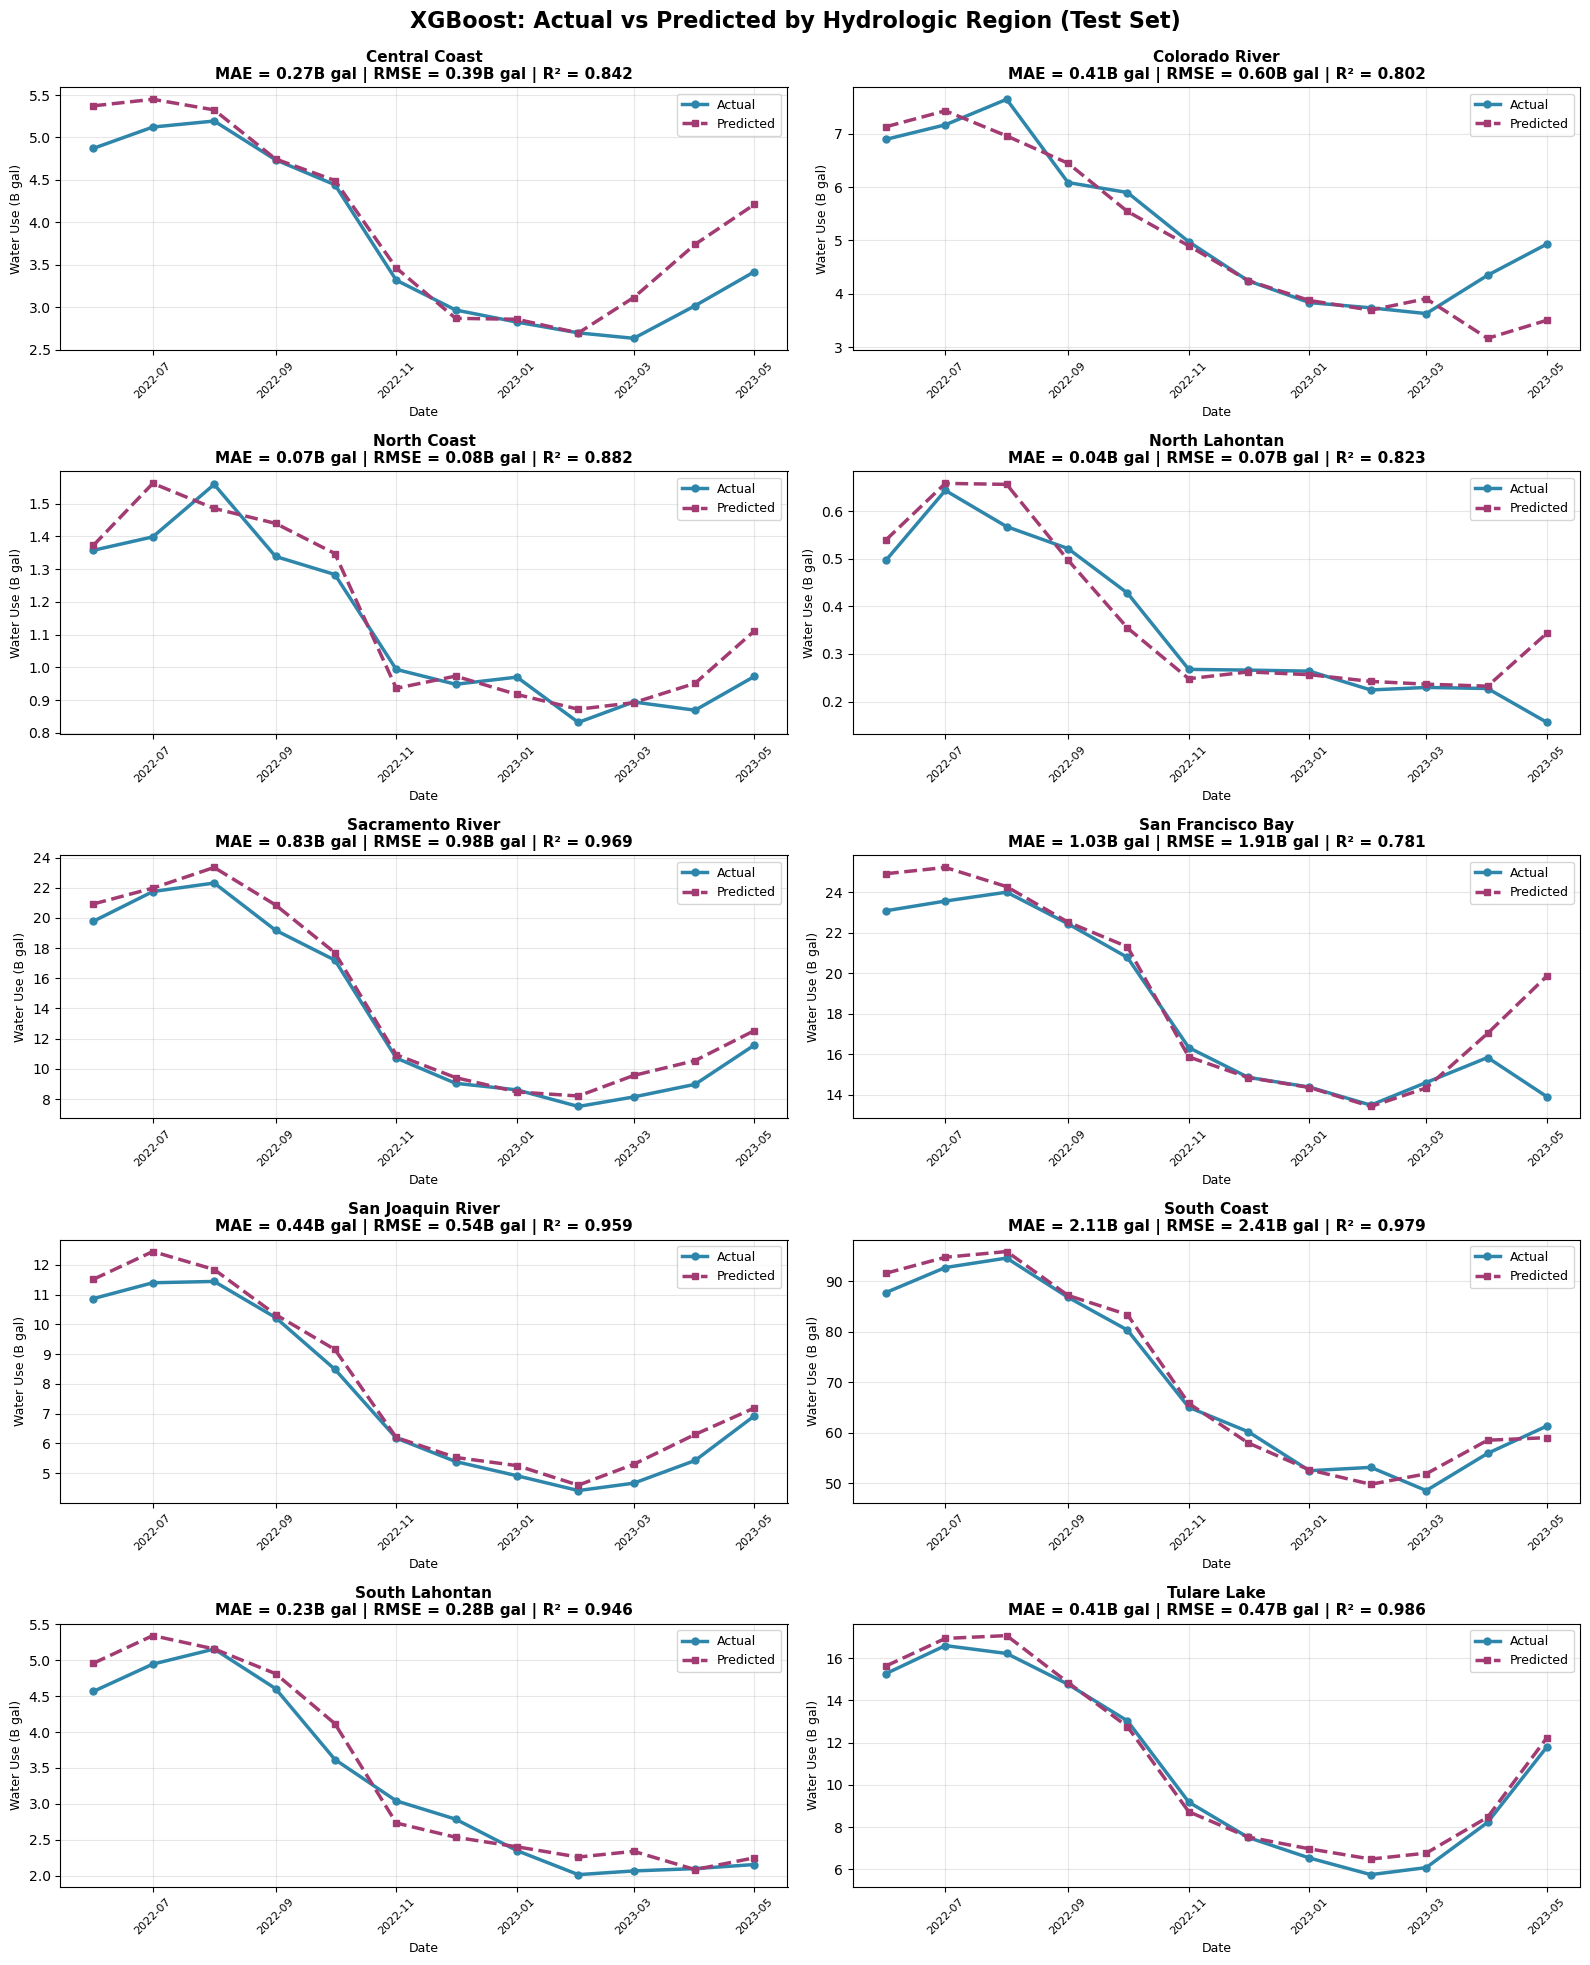

In [55]:
xgb_results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': xgb_pred,
    'region': final.loc[y_test.index, 'region'].values,
    'date': final.loc[y_test.index, 'report_date'].values
})

regions = sorted(xgb_results_df['region'].unique())
n_regions = len(regions)

# Create grid (5 rows x 2 columns for 10 regions)
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    region_data = xgb_results_df[xgb_results_df['region'] == region].sort_values('date')
    
    # Calculate metrics for this region
    mae_region = mean_absolute_error(region_data['actual'], region_data['predicted'])
    r2_region = r2_score(region_data['actual'], region_data['predicted'])
    rmse_region = np.sqrt(mean_squared_error(region_data['actual'], region_data['predicted']))
    
    # Plot
    ax.plot(region_data['date'], region_data['actual']/1e9, 
            label='Actual', marker='o', linewidth=2.5, markersize=5, color='#2E86AB')
    ax.plot(region_data['date'], region_data['predicted']/1e9, 
            label='Predicted', marker='s', linestyle='--', linewidth=2.5, markersize=5, color='#A23B72')
    
    # Styling
    ax.set_title(f'{region}\nMAE = {mae_region/1e9:.2f}B gal | RMSE = {rmse_region/1e9:.2f}B gal | R² = {r2_region:.3f}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Water Use (B gal)', fontsize=9)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('XGBoost: Actual vs Predicted by Hydrologic Region (Test Set)\n', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_predictions_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

### No Lagged Features

In [57]:
X_nolag = final.sort_values(['report_date', 'region']).drop(columns=['water_use', 'report_date', 'water_use_lastmonth', 'water_use_lastyear',
                                                                     'water_use_last3month_avg'])
y_nolag = final.sort_values(['report_date', 'region'])['water_use']

train_size = len(y) - 120 # 12 months of test multiplied by 10 regions
X_train_nolag, X_test_nolag = X_nolag[:train_size], X_nolag[train_size:]
y_train_nolag, y_test_nolag = y_nolag[:train_size], y_nolag[train_size:]
y_train_log_nolag = np.log1p(y_train_nolag)

In [58]:
xgb_model_nolag = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb)
])

xgb_tuned_nolag = BayesSearchCV(
    estimator=xgb_model_nolag,
    search_spaces=search_space,
    n_iter=60,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit='neg_root_mean_squared_error',
    return_train_score=True,
    random_state=52,
    verbose=0
)

In [59]:
xgb_tuned_nolag.fit(X_train_nolag, y_train_log_nolag)

best_xgb_nolag = xgb_tuned_nolag.best_estimator_
print('Best params: ', xgb_tuned_nolag.best_params_)
print('Best CV RMSE: ', xgb_tuned_nolag.best_score_)
best_xgb_nolag

Best params:  OrderedDict({'xgb__colsample_bytree': 0.776374129847902, 'xgb__gamma': 0.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 10, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 2000, 'xgb__reg_alpha': 0.0, 'xgb__reg_lambda': 1.0, 'xgb__subsample': 0.999160535334001})
Best CV RMSE:  -0.11282365016605031


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.776374129847902, device=None,
                              early_stopping_rounds=None,
                              enable_categor...
                              feature_types=None, feature_weights=None,
                              gamma=0.0, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=2000,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [60]:
xgb_pred_log_nolag = best_xgb_nolag.predict(X_test_nolag)
xgb_pred_nolag = np.expm1(xgb_pred_log_nolag)

mae_xgb_nolag = mean_absolute_error(y_test_nolag, xgb_pred_nolag)
rmse_xgb_nolag = np.sqrt(mean_squared_error(y_test_nolag, xgb_pred_nolag))
r_sq_xgb_nolag = r2_score(y_test_nolag, xgb_pred_nolag)

print(f"MAE: {mae_xgb_nolag:,.0f} gallons")
print(f"RMSE: {rmse_xgb_nolag:,.0f} gallons")
print('R²: ', r_sq_xgb_nolag)

MAE: 816,421,347 gallons
RMSE: 1,559,415,543 gallons
R²:  0.9941871367246206


## Model Comparison

In [62]:
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"SARIMAX (avg across 10 regions):")
print(f"Average MAE: {results_df['mae'].mean():,.0f} gallons")
print(f"Average RMSE: {results_df['rmse'].mean():,.0f} gallons")
print(f"Average R²: {results_df['r2'].mean():.3f}")

print(f"\nXGBoost (unified model):")
print(f"MAE: {mae_xgb:,.0f} gallons")
print(f"RMSE: {rmse_xgb:,.0f} gallons")
print(f"R²: {r_sq_xgb:.3f}")

print(f"\nImprovement:")
print(f"MAE improvement: {(results_df['mae'].mean() - mae_xgb)/1e9:.2f}B gallons ({(results_df['mae'].mean() - mae_xgb)/results_df['mae'].mean()*100:.1f}%)")
print(f"RMSE improvement: {(results_df['rmse'].mean() - rmse_xgb)/1e9:.3f}B gallons ({(results_df['rmse'].mean() - rmse_xgb)/results_df['rmse'].mean()*100:.1f}%)")
print(f"R² improvement: {(r_sq_xgb - results_df['r2'].mean()):.3f} ({(r_sq_xgb - results_df['r2'].mean())/results_df['r2'].mean()*100:.1f}%)")

MODEL COMPARISON
SARIMAX (avg across 10 regions):
Average MAE: 994,611,184 gallons
Average RMSE: 1,179,409,256 gallons
Average R²: 0.871

XGBoost (unified model):
MAE: 584,433,680 gallons
RMSE: 1,074,618,702 gallons
R²: 0.997

Improvement:
MAE improvement: 0.41B gallons (41.2%)
RMSE improvement: 0.105B gallons (8.9%)
R² improvement: 0.126 (14.4%)


## Predicting Future Water Use

Since this project is focusing on scenario-based modeling, I will predict future water use given two scenarios: one assuming that the climate is historically normal, and another assuming a consistent drought.

### XGBoost

#### Preparing Mock Prediction Features

In [80]:
# load 2025 data for lagged features

# climate data
climate_2025 = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\all_prism_hr_stats.csv')
climate_2025 = pd.pivot_table(climate_2025,
                              values='MEAN',
                              index=['HR_NAME', 'year_month', 'year', 'month'],
                              columns='variable',
                              aggfunc='first').reset_index()
climate_2025.columns.name = None
climate_2025 = climate_2025[climate_2025['year'] >= 2023]
climate_2025['year_month'] = pd.to_datetime(climate_2025['year_month'], format='%Y%m').dt.to_period('M')
climate_2025 = climate_2025.rename(columns={'HR_NAME': 'region',
                                            'year_month': 'report_date'})
climate_2025['report_date'] = pd.to_datetime(climate_2025[['year', 'month']].assign(day=1))


# water usage data
water_usage_2025 = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\monthly_combined_dataset.csv')
water_usage_2025['REPORT_PERIOD_START_DATE'] = pd.to_datetime(water_usage_2025['REPORT_PERIOD_START_DATE'])
water_usage_2025 = water_usage_2025[water_usage_2025['REPORT_PERIOD_START_DATE'].dt.year >= 2023]
water_usage_2025['month'] = water_usage_2025['REPORT_PERIOD_START_DATE'].dt.month
water_usage_2025['year'] = water_usage_2025['REPORT_PERIOD_START_DATE'].dt.year
keep_columns = ['SUPPLIER_NAME', 'HYDRO_REGION', 'REPORT_PERIOD_START_DATE', 'month', 'year',
                'POP_REPORT_PERIOD', 'POTABLE_SUPPLY_GAL']
water_usage_2025 = water_usage_2025[keep_columns]
water_usage_2025['REPORT_PERIOD_START_DATE'] = water_usage_2025['REPORT_PERIOD_START_DATE'].dt.to_period('M')
water_usage_2025 = water_usage_2025.rename(columns={
    'HYDRO_REGION': 'region',
    'REPORT_PERIOD_START_DATE': 'date',
    'POP_REPORT_PERIOD': 'population',
    'POTABLE_SUPPLY_GAL': 'water_use'
})
water_usage_2025 = water_usage_2025.groupby(['region', 'year', 'month']).agg({
    'water_use': 'sum',
    'population': 'sum'
}).reset_index()
water_usage_2025['report_date'] = pd.to_datetime(water_usage_2025[['year', 'month']].assign(day=1))


# land cover data
land_cover_2025 = pd.read_csv('C:\\Users\\gtapa\\Desktop\\SDSU\\Fall 2025\\BDA 600\\Data\\nlcd_all_years.csv')
land_cover_2025 = land_cover_2025[land_cover_2025['year'] >= 2023]
value_cols = [c for c in land_cover_2025.columns if c.startswith('VALUE_')]
land_cover_2025['total_area'] = land_cover_2025[value_cols].sum(axis=1)
for col in value_cols:
    land_cover_2025[col] = land_cover_2025[col] / land_cover_2025['total_area']
land_cover_2025['pct_developed'] = land_cover_2025[['VALUE_21', 'VALUE_22', 'VALUE_23', 'VALUE_24']].sum(axis=1)
land_cover_2025['pct_agriculture'] = land_cover_2025[['VALUE_81', 'VALUE_82']].sum(axis=1)
land_cover_2025['pct_forest'] = land_cover_2025[['VALUE_41', 'VALUE_42', 'VALUE_43']].sum(axis=1)
land_cover_2025['pct_shrub_grass'] = land_cover_2025[['VALUE_52', 'VALUE_71']].sum(axis=1)
land_cover_2025.rename(columns={'HR_NAME': 'region'}, inplace=True)
land_2024 = land_cover_2025[land_cover_2025['year'] == 2024].copy()
land_2024['year'] = 2025
land_cover_2025 = pd.concat([land_cover_2025, land_2024], ignore_index=True)
land_cover_2025.drop(columns=value_cols, inplace=True)
land_cover_2025.drop(columns='total_area', inplace=True)
land_cover_2025 = land_cover_2025[land_cover_2025['year'] >= 2023]

In [82]:
final_2025 = water_usage_2025.merge(climate_2025,
                        on=['region', 'year', 'month'],
                        how='inner')

if 'report_date_x' in final_2025.columns:
    final_2025 = final_2025.rename(columns={'report_date_x': 'report_date'})
    final_2025 = final_2025.drop(columns=['report_date_y'])

final_2025 = final_2025.merge(land_cover_2025, on=['region', 'year'], how='left')

final_2025 = final_2025.sort_values(['region', 'year', 'month'])

# Lag features
final_2025['water_use_lastmonth'] = final_2025.groupby('region')['water_use'].shift(1)  # Previous month
final_2025['water_use_lastyear'] = final_2025.groupby('region')['water_use'].shift(12)  # Same month last year

# Rolling averages
final_2025['water_use_last3month_avg'] = final_2025.groupby('region')['water_use'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

# 3 month precipitation total, captures drought buildup
final_2025['ppt_3month_total'] = final_2025.groupby('region')['ppt'].transform(
    lambda x: x.rolling(3, min_periods=1).sum())

# 3 month average temperature
final_2025['tmax_3month_avg'] = final_2025.groupby('region')['tmax'].transform(
    lambda x: x.rolling(3, min_periods=1).mean())

# cyclical encoding for months, helps with seasonality influence on water usage
final_2025['month_sin'] = np.sin(2 * np.pi * final_2025['month'] / 12)
final_2025['month_cos'] = np.cos(2 * np.pi * final_2025['month'] / 12)

col_order = ['region', 'report_date', 'year', 'month', 
             'month_sin', 'month_cos',
             'ppt', 'ppt_3month_total',
             'tmax', 'tmax_3month_avg',
             'population',
             'pct_developed', 'pct_agriculture', 'pct_forest', 'pct_shrub_grass',
             'water_use_lastmonth', 'water_use_lastyear', 'water_use_last3month_avg', 'water_use']

final_2025 = final_2025[col_order]

In [84]:
historical_data = pd.concat(
    [final[final['year'] != 2023], final_2025], ignore_index=True
).sort_values(['region', 'report_date'])

In [142]:
def recursive_forecast_xgboost(model, base_data, start_date, end_date, feature_cols, scenario='baseline'):
    """
    Perform recursive forecasting with XGBoost model using lag features.
    
    Parameters:
    - model: Trained XGBoost model (with lag features)
    - base_data: DataFrame with historical data up to start_date
    - start_date: First month to forecast (e.g., '2025-10-01')
    - end_date: Last month to forecast (e.g., '2026-12-31')
    - feature_cols: List of feature column names used by model
    
    Returns:
    - DataFrame with predictions
    """
    
    # Create date range for forecasting
    future_dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    
    # Make a copy to avoid modifying original
    working_data = base_data.copy()
    
    # Store predictions
    predictions = []
    
    # Get unique regions
    regions = working_data['region'].unique()
    
    print(f"Starting recursive forecast for {len(future_dates)} months across {len(regions)} regions...")
    
    for date_idx, future_date in enumerate(future_dates):
        print(f"Forecasting: {future_date.strftime('%Y-%m')} ({date_idx+1}/{len(future_dates)})")
        
        month_predictions = []
        
        for region in regions:
            # Get all historical data for this region (including previous predictions)
            region_data = working_data[working_data['region'] == region].sort_values('report_date')
            
            # Get the latest row as template
            template = region_data.iloc[-1].copy()
            
            # Update temporal features
            template['report_date'] = future_date
            template['year'] = future_date.year
            template['month'] = future_date.month
            template['month_sin'] = np.sin(2 * np.pi * future_date.month / 12)
            template['month_cos'] = np.cos(2 * np.pi * future_date.month / 12)
            
            # Update climate features (use historical monthly average)
            historical_region = base_data[
                (base_data['region'] == region) & 
                (base_data['month'] == future_date.month)
            ]
            
            if scenario == 'baseline':
                template['ppt'] = historical_region['ppt'].mean()
                template['ppt_3month_total'] = historical_region['ppt_3month_total'].mean()
                template['tmax'] = historical_region['tmax'].mean()
                template['tmax_3month_avg'] = historical_region['tmax_3month_avg'].mean()
                years_forward = (future_date - region_data['report_date'].iloc[-1]).days / 365.25
                template['population'] = template['population'] * (1.01 ** years_forward)

            elif scenario == 'drought':
                template['ppt'] = historical_region['ppt'].mean() * 0.6
                template['ppt_3month_total'] = historical_region['ppt_3month_total'].mean() * 0.6
                template['tmax'] = historical_region['tmax'].mean() + 2
                template['tmax_3month_avg'] = historical_region['tmax_3month_avg'].mean() + 2
                years_forward = (future_date - region_data['report_date'].iloc[-1]).days / 365.25
                template['population'] = template['population'] * (1.01 ** years_forward)

            elif scenario == 'wet':
                template['ppt'] = historical_region['ppt'].mean() * 1.4
                template['ppt_3month_total'] = historical_region['ppt_3month_total'].mean() * 1.4
                template['tmax'] = historical_region['tmax'].mean() - 2 
                template['tmax_3month_avg'] = historical_region['tmax_3month_avg'].mean() - 2
                years_forward = (future_date - region_data['report_date'].iloc[-1]).days / 365.25
                template['population'] = template['population'] * (1.01 ** years_forward)

            elif scenario == 'climate change':
                template['ppt'] = historical_region['ppt'].mean() * 0.85
                template['ppt_3month_total'] = historical_region['ppt_3month_total'].mean() * 0.85
                template['tmax'] = historical_region['tmax'].mean() + 2
                template['tmax_3month_avg'] = historical_region['tmax_3month_avg'].mean() + 2
                years_forward = (future_date - region_data['report_date'].iloc[-1]).days / 365.25
                template['population'] = template['population'] * (1.025 ** years_forward)

            elif scenario == 'urbanization':
                template['ppt'] = historical_region['ppt'].mean()
                template['ppt_3month_total'] = historical_region['ppt_3month_total'].mean()
                template['tmax'] = historical_region['tmax'].mean()
                template['tmax_3month_avg'] = historical_region['tmax_3month_avg'].mean()
                # original means
                d = historical_region['pct_developed'].mean()
                a = historical_region['pct_agriculture'].mean()
                f = historical_region['pct_forest'].mean()
                s = historical_region['pct_shrub_grass'].mean()
                new_d = d * 1.2     # increase developed_pct by 20%
                # renormalize the others
                remaining_sum = a + f + s
                scale = (1 - new_d) / remaining_sum
                new_a = a * scale
                new_f = f * scale
                new_s = s * scale
                # Assign to template
                template['pct_developed'] = new_d
                template['pct_agriculture'] = new_a
                template['pct_forest'] = new_f
                template['pct_shrub_grass'] = new_s 
                years_forward = (future_date - region_data['report_date'].iloc[-1]).days / 365.25
                template['population'] = template['population'] * (1.015 ** years_forward)     # 1.5% population annual growth instead of 1%
            
            # Land use stays the same (already in template)
            
            # === CALCULATE LAG FEATURES ===
            
            # 1. water_use_lastmonth: Previous month (last row in region_data)
            template['water_use_lastmonth'] = region_data.iloc[-1]['water_use']
            
            # 2. water_use_lastyear: Same month from previous year
            lastyear_data = region_data[
                (region_data['year'] == future_date.year - 1) & 
                (region_data['month'] == future_date.month)
            ]
            
            if len(lastyear_data) > 0:
                # Use actual value from last year
                template['water_use_lastyear'] = lastyear_data['water_use'].iloc[-1]
            else:
                # Fallback: use historical average for this month
                historical_month = base_data[
                    (base_data['region'] == region) & 
                    (base_data['month'] == future_date.month)
                ]
                template['water_use_lastyear'] = historical_month['water_use'].mean()
            
            # 3. water_use_last3month_avg: Average of last 3 months
            if len(region_data) >= 3:
                template['water_use_last3month_avg'] = region_data.iloc[-3:]['water_use'].mean()
            else:
                template['water_use_last3month_avg'] = region_data['water_use'].mean()
            
            # === PREDICT ===
            
            # Prepare features for prediction
            X_pred = pd.DataFrame([template])[feature_cols]
            
            # Make prediction
            prediction_log = model.predict(X_pred)[0]
            prediction = np.expm1(prediction_log)
            
            # Store prediction in template
            template['water_use'] = prediction
            
            # Add to month predictions
            month_predictions.append(template)
        
        # Convert month predictions to DataFrame
        month_df = pd.DataFrame(month_predictions)
        
        # Append to working data (so next month can use these predictions as lags)
        working_data = pd.concat([working_data, month_df], ignore_index=True)
        
        # Store for final output
        predictions.append(month_df)
    
    # Combine all predictions
    forecast_df = pd.concat(predictions, ignore_index=True)
    
    print(f"Forecast complete! Generated {len(forecast_df)} predictions.")
    
    return forecast_df

#### Scenario One: Baseline (Historical Average)

In [116]:
feature_cols = [
    'region', 'year', 'month', 'month_sin', 'month_cos', 
    'ppt', 'ppt_3month_total', 'tmax', 'tmax_3month_avg', 
    'population', 'pct_developed', 
    'pct_agriculture', 'pct_forest', 'pct_shrub_grass',
    'water_use_lastmonth', 'water_use_lastyear', 'water_use_last3month_avg'
]

In [158]:
# Run recursive forecast
forecast_2026 = recursive_forecast_xgboost(
    model=best_xgb,
    base_data=historical_data,  # Data through September 2025
    start_date='2025-10-01',  # Start forecasting from October 2025
    end_date='2026-12-31',  # Through December 2026
    feature_cols=feature_cols
)

print("\nForecast Summary:")
print(forecast_2026.groupby('region')['water_use'].describe())

Starting recursive forecast for 15 months across 10 regions...
Forecasting: 2025-10 (1/15)
Forecasting: 2025-11 (2/15)
Forecasting: 2025-12 (3/15)
Forecasting: 2026-01 (4/15)
Forecasting: 2026-02 (5/15)
Forecasting: 2026-03 (6/15)
Forecasting: 2026-04 (7/15)
Forecasting: 2026-05 (8/15)
Forecasting: 2026-06 (9/15)
Forecasting: 2026-07 (10/15)
Forecasting: 2026-08 (11/15)
Forecasting: 2026-09 (12/15)
Forecasting: 2026-10 (13/15)
Forecasting: 2026-11 (14/15)
Forecasting: 2026-12 (15/15)
Forecast complete! Generated 150 predictions.

Forecast Summary:
                   count          mean           std           min  \
region                                                               
Central Coast       15.0  4.082553e+09  9.568030e+08  2.915653e+09   
Colorado River      15.0  2.617655e+09  4.743825e+08  1.828597e+09   
North Coast         15.0  1.150315e+09  2.590777e+08  8.512154e+08   
North Lahontan      15.0  3.017873e+08  8.777866e+07  2.320241e+08   
Sacramento River    15.0  

#### Scenario Two: Drought Conditions

In [160]:
forecast_2026_drought = recursive_forecast_xgboost(
    model=best_xgb,  # Your trained model with lag features
    base_data=historical_data,  # Data through September 2025
    start_date='2025-10-01',  # Start forecasting from October 2025
    end_date='2026-12-31',  # Through December 2026
    feature_cols=feature_cols,
    scenario='drought'
)

print("\nForecast Summary:")
print(forecast_2026_drought.groupby('region')['water_use'].describe())

Starting recursive forecast for 15 months across 10 regions...
Forecasting: 2025-10 (1/15)
Forecasting: 2025-11 (2/15)
Forecasting: 2025-12 (3/15)
Forecasting: 2026-01 (4/15)
Forecasting: 2026-02 (5/15)
Forecasting: 2026-03 (6/15)
Forecasting: 2026-04 (7/15)
Forecasting: 2026-05 (8/15)
Forecasting: 2026-06 (9/15)
Forecasting: 2026-07 (10/15)
Forecasting: 2026-08 (11/15)
Forecasting: 2026-09 (12/15)
Forecasting: 2026-10 (13/15)
Forecasting: 2026-11 (14/15)
Forecasting: 2026-12 (15/15)
Forecast complete! Generated 150 predictions.

Forecast Summary:
                   count          mean           std           min  \
region                                                               
Central Coast       15.0  4.226462e+09  9.501381e+08  2.993119e+09   
Colorado River      15.0  2.748687e+09  4.487746e+08  1.972724e+09   
North Coast         15.0  1.181202e+09  2.619384e+08  8.520113e+08   
North Lahontan      15.0  3.083525e+08  8.909978e+07  2.291876e+08   
Sacramento River    15.0  

#### Scenario Three: Wet Year

In [162]:
forecast_2026_wet = recursive_forecast_xgboost(
    model=best_xgb,  # Your trained model with lag features
    base_data=historical_data,  # Data through September 2025
    start_date='2025-10-01',  # Start forecasting from October 2025
    end_date='2026-12-31',  # Through December 2026
    feature_cols=feature_cols,
    scenario='wet'
)

print("\nForecast Summary:")
print(forecast_2026_wet.groupby('region')['water_use'].describe())

Starting recursive forecast for 15 months across 10 regions...
Forecasting: 2025-10 (1/15)
Forecasting: 2025-11 (2/15)
Forecasting: 2025-12 (3/15)
Forecasting: 2026-01 (4/15)
Forecasting: 2026-02 (5/15)
Forecasting: 2026-03 (6/15)
Forecasting: 2026-04 (7/15)
Forecasting: 2026-05 (8/15)
Forecasting: 2026-06 (9/15)
Forecasting: 2026-07 (10/15)
Forecasting: 2026-08 (11/15)
Forecasting: 2026-09 (12/15)
Forecasting: 2026-10 (13/15)
Forecasting: 2026-11 (14/15)
Forecasting: 2026-12 (15/15)
Forecast complete! Generated 150 predictions.

Forecast Summary:
                   count          mean           std           min  \
region                                                               
Central Coast       15.0  3.883181e+09  9.501829e+08  2.778392e+09   
Colorado River      15.0  2.551430e+09  4.761797e+08  1.749394e+09   
North Coast         15.0  1.131624e+09  2.515306e+08  8.633841e+08   
North Lahontan      15.0  2.903323e+08  8.504478e+07  2.321972e+08   
Sacramento River    15.0  

#### Scenario Four: Climate Change Conditions

In [163]:
forecast_2026_cc = recursive_forecast_xgboost(
    model=best_xgb,  # Your trained model with lag features
    base_data=historical_data,  # Data through September 2025
    start_date='2025-10-01',  # Start forecasting from October 2025
    end_date='2026-12-31',  # Through December 2026
    feature_cols=feature_cols,
    scenario='climate change'
)

print("\nForecast Summary:")
print(forecast_2026_cc.groupby('region')['water_use'].describe())

Starting recursive forecast for 15 months across 10 regions...
Forecasting: 2025-10 (1/15)
Forecasting: 2025-11 (2/15)
Forecasting: 2025-12 (3/15)
Forecasting: 2026-01 (4/15)
Forecasting: 2026-02 (5/15)
Forecasting: 2026-03 (6/15)
Forecasting: 2026-04 (7/15)
Forecasting: 2026-05 (8/15)
Forecasting: 2026-06 (9/15)
Forecasting: 2026-07 (10/15)
Forecasting: 2026-08 (11/15)
Forecasting: 2026-09 (12/15)
Forecasting: 2026-10 (13/15)
Forecasting: 2026-11 (14/15)
Forecasting: 2026-12 (15/15)
Forecast complete! Generated 150 predictions.

Forecast Summary:
                   count          mean           std           min  \
region                                                               
Central Coast       15.0  4.215245e+09  9.513860e+08  2.994376e+09   
Colorado River      15.0  2.674790e+09  4.450395e+08  1.928133e+09   
North Coast         15.0  1.183984e+09  2.534209e+08  8.749404e+08   
North Lahontan      15.0  3.082705e+08  8.954453e+07  2.296874e+08   
Sacramento River    15.0  

#### Scenario Five: Urbanization

In [166]:
forecast_2026_urban = recursive_forecast_xgboost(
    model=best_xgb,  # Your trained model with lag features
    base_data=historical_data,  # Data through September 2025
    start_date='2025-10-01',  # Start forecasting from October 2025
    end_date='2026-12-31',  # Through December 2026
    feature_cols=feature_cols,
    scenario='urbanization'
)

print("\nForecast Summary:")
print(forecast_2026_urban.groupby('region')['water_use'].describe())

Starting recursive forecast for 15 months across 10 regions...
Forecasting: 2025-10 (1/15)
Forecasting: 2025-11 (2/15)
Forecasting: 2025-12 (3/15)
Forecasting: 2026-01 (4/15)
Forecasting: 2026-02 (5/15)
Forecasting: 2026-03 (6/15)
Forecasting: 2026-04 (7/15)
Forecasting: 2026-05 (8/15)
Forecasting: 2026-06 (9/15)
Forecasting: 2026-07 (10/15)
Forecasting: 2026-08 (11/15)
Forecasting: 2026-09 (12/15)
Forecasting: 2026-10 (13/15)
Forecasting: 2026-11 (14/15)
Forecasting: 2026-12 (15/15)
Forecast complete! Generated 150 predictions.

Forecast Summary:
                   count          mean           std           min  \
region                                                               
Central Coast       15.0  4.892397e+09  1.143414e+09  3.321845e+09   
Colorado River      15.0  2.524174e+09  4.465025e+08  1.768551e+09   
North Coast         15.0  1.179652e+09  2.622727e+08  8.550948e+08   
North Lahontan      15.0  3.079602e+08  9.216770e+07  2.306695e+08   
Sacramento River    15.0  

#### Combined Visualization

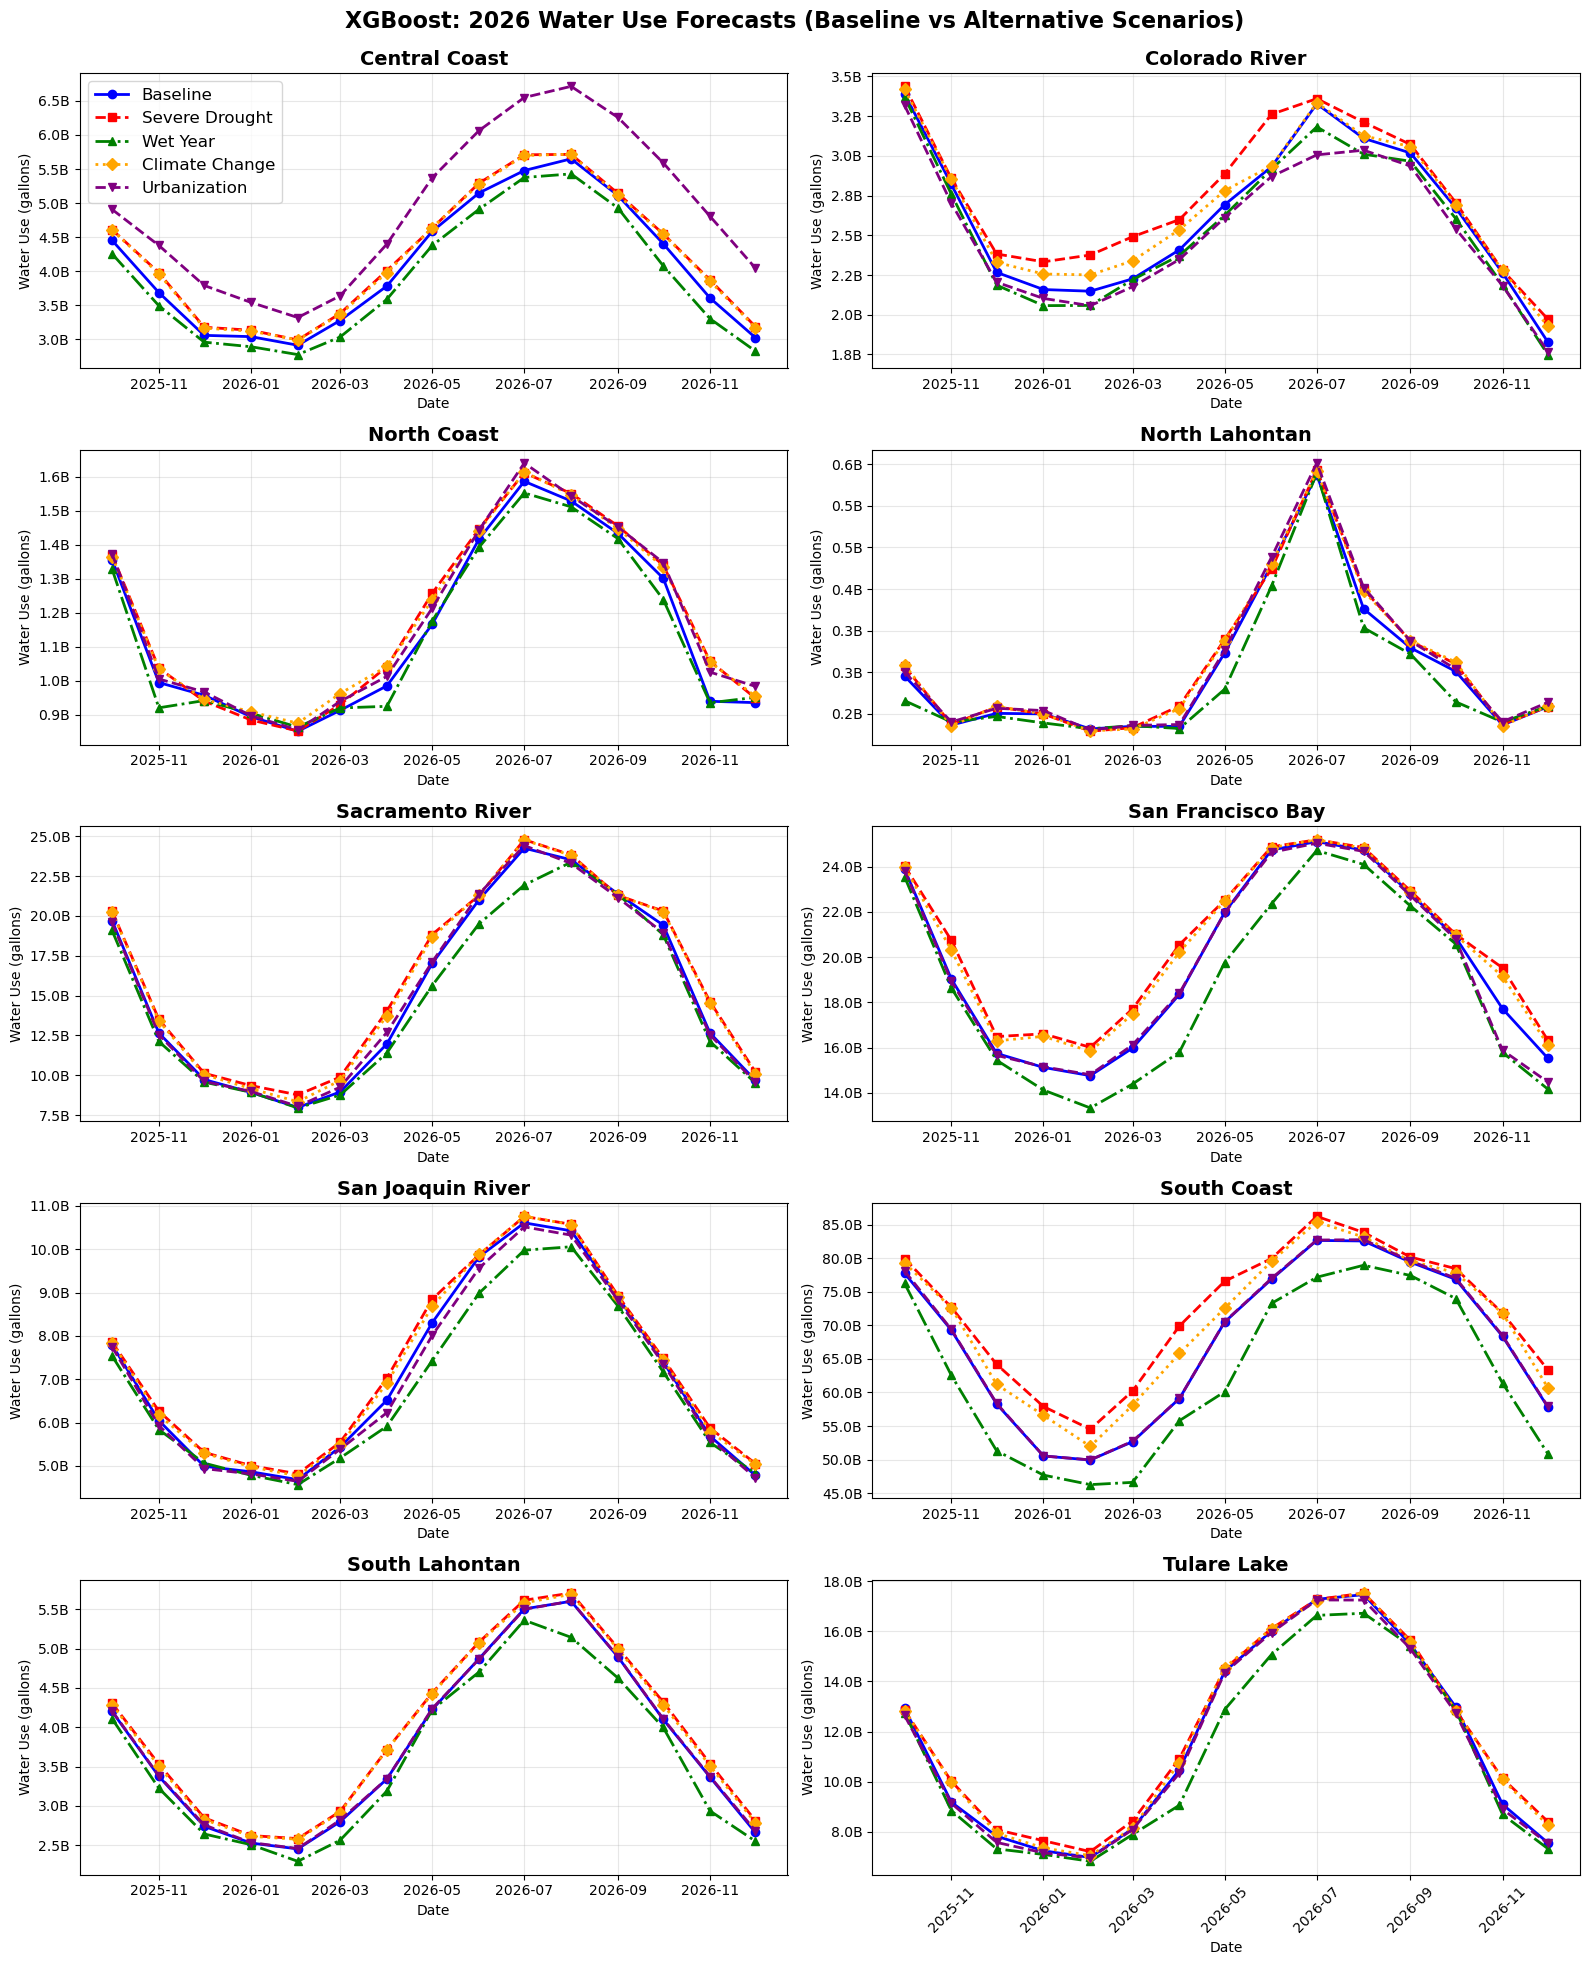

In [190]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

future_dates = pd.date_range(start='2025-10-01', end='2026-12-01', freq='MS')

for idx, region in enumerate(forecast_2026['region'].unique()):
    ax = axes[idx]
    
    ax.plot(future_dates, 
            forecast_2026[forecast_2026['region'] == region]['water_use'],
            label='Baseline', linewidth=2, color='blue', marker='o')

    ax.plot(future_dates, 
            forecast_2026_drought[forecast_2026_drought['region'] == region]['water_use'],
            label='Severe Drought', linewidth=2, color='red', linestyle='--', marker='s')

    ax.plot(future_dates, 
            forecast_2026_wet[forecast_2026_wet['region'] == region]['water_use'],
            label='Wet Year', linewidth=2, color='green', linestyle='-.', marker='^')

    ax.plot(future_dates, 
            forecast_2026_cc[forecast_2026_cc['region'] == region]['water_use'],
            label='Climate Change', linewidth=2, color='orange', linestyle=':', marker='D')

    ax.plot(future_dates, 
            forecast_2026_urban[forecast_2026_urban['region'] == region]['water_use'],
            label='Urbanization', linewidth=2, color='purple', linestyle='--', marker='v')

    # Only add legend to the FIRST subplot
    if idx == 0:
        ax.legend(fontsize=12)
    else:
        ax.legend().remove()

    ax.set_title(f'{region}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Water Use (gallons)')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
    plt.xticks(rotation=45)

plt.suptitle('XGBoost: 2026 Water Use Forecasts (Baseline vs Alternative Scenarios)\n',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_2026_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [168]:
forecast_2026.to_csv('xgboost_2026_baseline.csv', index=False)
forecast_2026_drought.to_csv('xgboost_2026_drought.csv', index=False)
forecast_2026_wet.to_csv('xgboost_2026_wet.csv', index=False)
forecast_2026_cc.to_csv('xgboost_2026_cc.csv', index=False)
forecast_2026_urban.to_csv('xgboost_2026_urban.csv', index=False)

In [82]:
baseline = pd.read_csv(r"C:\Users\gtapa\Desktop\SDSU\Fall 2025\BDA 600\Results\xgboost_2026_baseline.csv")
drought = pd.read_csv(r"C:\Users\gtapa\Desktop\SDSU\Fall 2025\BDA 600\Results\xgboost_2026_drought.csv")
wet = pd.read_csv(r"C:\Users\gtapa\Desktop\SDSU\Fall 2025\BDA 600\Results\xgboost_2026_wet.csv")
cc = pd.read_csv(r"C:\Users\gtapa\Desktop\SDSU\Fall 2025\BDA 600\Results\xgboost_2026_cc.csv")
urban = pd.read_csv(r"C:\Users\gtapa\Desktop\SDSU\Fall 2025\BDA 600\Results\xgboost_2026_urban.csv")

In [84]:
keep_columns = ['region', 'report_date', 'year', 'month', 'population', 'pct_developed', 'pct_agriculture', 'pct_forest', 'water_use']
baseline = baseline[keep_columns]
drought = drought[keep_columns]
wet = wet[keep_columns]
cc = cc[keep_columns]
urban = urban[keep_columns]

baseline['scenario'] = 'Baseline'
drought['scenario'] = 'Severe Drought'
wet['scenario'] = 'Wet Year'
cc['scenario'] = 'Climate Change'
urban['scenario'] = 'Urbanization'

scenario_results = pd.concat([baseline, drought, wet, cc, urban], ignore_index=True).sort_values(['region', 'report_date'])
scenario_results = scenario_results[scenario_results['year'] == 2026]

In [86]:
def calculate_risk_index(
    scenarios_df,
    baseline_scenario='Baseline',
    stress_scenarios=('Severe Drought',)  # can be a list/tuple of names
):
    """
    Calculate comprehensive risk index for one or more stress scenarios.
    """
    # Baseline metrics (same for all stress scenarios)
    baseline = scenarios_df[scenarios_df['scenario'] == baseline_scenario].groupby('region').agg({
        'water_use': 'mean',
        'population': 'mean',
        'pct_developed': 'mean',
        'pct_agriculture': 'mean'
    })

    all_results = []  # collect per-scenario risk tables here

    # Ensure stress_scenarios is iterable
    if isinstance(stress_scenarios, str):
        stress_scenarios = [stress_scenarios]

    for stress_scenario in stress_scenarios:
        # 1) Get stress-scenario water use
        drought = scenarios_df[scenarios_df['scenario'] == stress_scenario].groupby('region').agg({
            'water_use': 'mean'
        })

        # 2) Construct risk_data relative to baseline
        risk_data = baseline.copy()

        # factor 1: % increase under drought (demand shock)
        risk_data['pct_increase'] = (drought['water_use'] - baseline['water_use']) / baseline['water_use'] * 100

        # factor 2: Absolute water use (scale)
        risk_data['absolute_use'] = baseline['water_use']

        # factor 3: Population (people affected)
        risk_data['population'] = baseline['population']

        # factor 4: Urban dependence
        risk_data['urban_pct'] = baseline['pct_developed']

        # factor 5: Agricultural exposure
        risk_data['agriculture_pct'] = baseline['pct_agriculture']

        # factor 6: Per capita use (efficiency - higher = less efficient)
        risk_data['per_capita_use'] = baseline['water_use'] / baseline['population']

        # 3) Normalize to 0–100 *within this stress scenario*
        scaler = MinMaxScaler(feature_range=(0, 100))

        risk_data['pct_increase_norm']      = scaler.fit_transform(risk_data[['pct_increase']])
        risk_data['absolute_use_norm']      = scaler.fit_transform(risk_data[['absolute_use']])
        risk_data['population_norm']        = scaler.fit_transform(risk_data[['population']])
        risk_data['urban_pct_norm']         = scaler.fit_transform(risk_data[['urban_pct']])
        risk_data['agriculture_pct_norm']   = scaler.fit_transform(risk_data[['agriculture_pct']])
        risk_data['per_capita_use_norm']    = scaler.fit_transform(risk_data[['per_capita_use']])

        # 4) Weighted risk index
        weights = {
            'pct_increase_norm':    0.25,  # Demand shock
            'absolute_use_norm':    0.15,  # Scale of impact
            'population_norm':      0.15,  # People affected
            'urban_pct_norm':       0.20,  # Urban vulnerability
            'agriculture_pct_norm': 0.125, # Ag system stress
            'per_capita_use_norm':  0.125, # Efficiency / waste
        }

        risk_data['risk_index'] = sum(
            risk_data[factor] * weight
            for factor, weight in weights.items()
        )

        # 5) Risk category
        risk_data['risk_category'] = pd.cut(
            risk_data['risk_index'],
            bins=[0, 25, 50, 75, 100],
            labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'],
            include_lowest=True
        )

        # 6) Tag with scenario name and store
        risk_data['stress_scenario'] = stress_scenario

        all_results.append(risk_data.reset_index())  # keep region as a column

    # Combine all stress scenarios into one DataFrame
    combined = pd.concat(all_results, ignore_index=True)
    return combined.sort_values(['stress_scenario', 'risk_index'], ascending=[True, False])

In [88]:
risk_assessment = calculate_risk_index(scenario_results,
                                       baseline_scenario='Baseline',
                                       stress_scenarios=('Severe Drought', 'Wet Year', 
                                                         'Climate Change', 'Urbanization'))

In [90]:
scenario_results.to_csv('xgboost_2026_predictions.csv', index=False)
risk_assessment.to_csv('risk_assessment.csv', index=False)